# ThermoMPNN + SWARM: первый эксперимент

Проверяем, помогает ли дополнительный обмен между признаками остатков
предсказывать изменение стабильности белка.

Сравниваем:
- исходный ThermoMPNN;
- новую MLP-голову;
- рекуррентную голову без межостаточного обмена;
- SWARM с общей сводкой.

ProteinMPNN заморожен. Новые головы обучаются с нуля.
Цель: ΔΔG в ккал/моль; положительное значение означает дестабилизацию.

Первый запуск — техническая проверка на небольшой части train/validation.
Тестовая выборка в этой тетрадке не используется.

Источники:
- https://github.com/Kuhlman-Lab/ThermoMPNN
- https://arxiv.org/abs/1906.09400
- https://github.com/zalandoresearch/SWARM

In [1]:
from pathlib import Path
from datetime import datetime
import copy
import hashlib
import json
import os
import pickle
import random
import subprocess
import sys
import time

import numpy as np
import pandas as pd
import torch
from torch import nn
from omegaconf import OmegaConf
from tqdm.auto import tqdm
from IPython.display import display


# Ищем корень проекта из корня или папки notebooks.
PROJECT_ROOT = next(
    (
        path
        for path in [Path.cwd(), *Path.cwd().parents]
        if (path / "external" / "ThermoMPNN" / "config.yaml").exists()
    ),
    None,
)
assert PROJECT_ROOT is not None, "Не найден external/ThermoMPNN"

THERMOMPNN_DIR = PROJECT_ROOT / "external" / "ThermoMPNN"

CSV_PATH = (
    PROJECT_ROOT / "data" / "megascale"
    / "Processed_K50_dG_datasets"
    / "Tsuboyama2023_Dataset2_Dataset3_20230416.csv"
)
PDB_DIR = (
    PROJECT_ROOT / "data" / "megascale" / "AlphaFold_model_PDBs"
)
SPLITS_PATH = THERMOMPNN_DIR / "dataset_splits" / "mega_splits.pkl"
CHECKPOINT_PATH = THERMOMPNN_DIR / "models" / "thermoMPNN_default.pt"

for path in [CSV_PATH, PDB_DIR, SPLITS_PATH, CHECKPOINT_PATH]:
    assert path.exists(), f"Не найдено: {path}"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_num_threads(min(4, os.cpu_count() or 1))

MODE = "trainval"  # "smoke" или "trainval"
assert MODE in {"smoke", "trainval"}

SEEDS = [42] if MODE == "smoke" else [42, 43, 44]
EPOCHS = 3 if MODE == "smoke" else 40

LEARNING_RATE = 1e-3
HIDDEN_DIM = 32
SWARM_STEPS = 3
MODEL_KINDS = ["mlp", "self", "swarm"]

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S_%f")
RESULTS_DIR = PROJECT_ROOT / "results" / f"swarm_{MODE}_{RUN_ID}"
WEIGHTS_DIR = PROJECT_ROOT / "weights" / f"swarm_{MODE}_{RUN_ID}"
CACHE_DIR = PROJECT_ROOT / "data" / "features" / "thermompnn"

for path in [RESULTS_DIR, WEIGHTS_DIR, CACHE_DIR]:
    path.mkdir(parents=True, exist_ok=True)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def sha256_file(path):
    digest = hashlib.sha256()
    with open(path, "rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("Устройство:", DEVICE)
print("Корень:", PROJECT_ROOT)
print("Режим:", MODE)
print("Результаты:", RESULTS_DIR)

Python: 3.10.21
PyTorch: 2.5.1+cpu
Устройство: cpu
Корень: /home/andre/Neuro_Project_Pilot
Режим: trainval
Результаты: /home/andre/Neuro_Project_Pilot/results/swarm_trainval_20260930_121141_532051


/home/andre/miniconda3/envs/NeuroPP/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Исходная модель

Загружаем тот же checkpoint, который использовали в baseline.
Он служит источником замороженных признаков и исходных прогнозов.

Новые обучаемые головы будут отдельными объектами.

In [2]:
EXPECTED_COMMIT = "370f76ec62bd929f7425e311d8df04a0d094990f"

actual_commit = subprocess.check_output(
    ["git", "-C", str(THERMOMPNN_DIR), "rev-parse", "HEAD"],
    text=True,
).strip()

assert actual_commit == EXPECTED_COMMIT, (
    f"Версия ThermoMPNN отличается: {actual_commit}"
)

checkpoint_sha = sha256_file(CHECKPOINT_PATH)
assert checkpoint_sha == (
    "af449118ccfb4e34971d802321907ed82a8a035ae80f055bf8fc56009a4a838a"
)

if str(THERMOMPNN_DIR) not in sys.path:
    sys.path.insert(0, str(THERMOMPNN_DIR))

from train_thermompnn import TransferModelPL
from protein_mpnn_utils import parse_PDB, tied_featurize
from datasets import Mutation
from transfer_model import ALPHABET

assert ALPHABET == "ACDEFGHIKLMNPQRSTVWYX"

cfg = OmegaConf.load(THERMOMPNN_DIR / "config.yaml")
cfg.platform = {
    "thermompnn_dir": str(THERMOMPNN_DIR),
    "accel": DEVICE.type,
}

reference = TransferModelPL.load_from_checkpoint(
    str(CHECKPOINT_PATH),
    cfg=cfg,
    map_location=DEVICE,
    strict=True,
)
reference.to(DEVICE).eval()
reference.requires_grad_(False)

core = reference.model
assert core.num_final_layers == 2
assert core.subtract_mut

feature_spec = {
    "format_version": 1,
    "commit": actual_commit,
    "checkpoint_sha256": checkpoint_sha,
    "proteinmpnn_sha256": sha256_file(
        THERMOMPNN_DIR / "vanilla_model_weights" / "v_48_020.pt"
    ),
    "source_sha256": {
        name: sha256_file(THERMOMPNN_DIR / name)
        for name in ["protein_mpnn_utils.py", "transfer_model.py"]
    },
    "model_config": OmegaConf.to_container(cfg.model, resolve=True),
    "torch": str(torch.__version__),
    "device": str(DEVICE),
}

FEATURE_SIGNATURE = hashlib.sha256(
    json.dumps(feature_spec, sort_keys=True).encode()
).hexdigest()

print("Исходная модель загружена.")
print("Обучаемых параметров в исходной модели:",
      sum(p.numel() for p in reference.parameters() if p.requires_grad))

/home/andre/miniconda3/envs/NeuroPP/lib/python3.10/site-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(
/home/andre/miniconda3/envs/NeuroPP/lib/python3.10/site-packages/lightning_fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary obj

Исходная модель загружена.
Обучаемых параметров в исходной модели: 0


/home/andre/miniconda3/envs/NeuroPP/lib/python3.10/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `SpearmanCorrcoef` will save all targets and predictions in the buffer. For large datasets, this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


## Данные и разбиение

Сохраняем официальное разбиение по белкам.
В коротком режиме используем первые 4 train-белка и 2 validation-белка.

Оставляем корректные одиночные замены с конечной числовой меткой.
Проверяем WT-последовательность, позицию и полную последовательность мутанта.

Наша цель: ddg_exp = -ddG_ML.

In [3]:
with open(SPLITS_PATH, "rb") as stream:
    splits = pickle.load(stream)

train_set = set(splits["train"])
val_set = set(splits["val"])
test_set = set(splits["test"])

assert train_set.isdisjoint(val_set)
assert train_set.isdisjoint(test_set)
assert val_set.isdisjoint(test_set)

train_names = sorted(train_set)
val_names = sorted(val_set)

if MODE == "smoke":
    train_names = train_names[:4]
    val_names = val_names[:2]

assert "1A32.pdb" in train_names

selected_names = train_names + val_names
selected_set = set(selected_names)

parts = []
for chunk in pd.read_csv(
    CSV_PATH,
    usecols=["WT_name", "mut_type", "aa_seq", "ddG_ML"],
    dtype=str,
    keep_default_na=False,
    chunksize=50_000,
):
    selected = chunk.loc[chunk["WT_name"].isin(selected_set)].copy()
    if not selected.empty:
        parts.append(selected)

assert parts, "Для выбранных белков не найдены строки"

raw = pd.concat(parts, ignore_index=True)
raw_by_name = {
    name: part.reset_index(drop=True)
    for name, part in raw.groupby("WT_name", sort=False)
}
assert selected_set == set(raw_by_name)

del parts, raw

print("Train-белков:", len(train_names))
print("Validation-белков:", len(val_names))
print("Тестовые данные не загружены.")

Train-белков: 239
Validation-белков: 31
Тестовые данные не загружены.


In [4]:
def prepare_mutations(part, sequence):
    wt_sequences = part.loc[
        part["mut_type"].eq("wt"), "aa_seq"
    ].unique()

    assert len(wt_sequences) == 1, "Неоднозначная WT-последовательность"
    assert wt_sequences[0] == sequence, "WT-последовательность не совпала с PDB"

    pieces = part["mut_type"].str.extract(
        r"^([ACDEFGHIKLMNPQRSTVWY])([1-9][0-9]*)([ACDEFGHIKLMNPQRSTVWY])$"
    )
    target = -pd.to_numeric(part["ddG_ML"], errors="coerce")

    keep = (
        pieces[0].notna()
        & pieces[0].ne(pieces[2])
        & np.isfinite(target)
    )

    rows = part.loc[
        keep, ["WT_name", "mut_type", "aa_seq"]
    ].copy()

    rows["index0"] = pieces.loc[keep, 1].astype(int) - 1
    rows["wt_aa"] = pieces.loc[keep, 0]
    rows["mut_aa"] = pieces.loc[keep, 2]
    rows["ddg_exp"] = target.loc[keep].astype(float)

    assert len(rows) > 0, "Нет подходящих одиночных мутаций"

    for row in rows.itertuples():
        i = row.index0
        assert 0 <= i < len(sequence)
        assert sequence[i] == row.wt_aa
        assert (
            row.aa_seq
            == sequence[:i] + row.mut_aa + sequence[i + 1:]
        )

    rows["wt_index"] = rows["wt_aa"].map(ALPHABET.index)
    rows["mut_index"] = rows["mut_aa"].map(ALPHABET.index)

    return rows.drop(columns="aa_seq").reset_index(drop=True)

## Замороженные признаки

Для каждого остатка извлекаем:
- 128 признаков последнего слоя декодера;
- 128 признаков предпоследнего слоя;
- 128 признаков WT-аминокислоты.

Получаем матрицу L × 384.

Обрабатываем по одному белку без padding.
Для первого эксперимента требуем полную последовательность и координаты.

Признаки и исходные оценки сохраняем в кэш.

In [5]:
def pdb_path_for(name):
    # Так же преобразуются имена в официальном загрузчике.
    stem = name.split(".pdb")[0].replace("|", ":")
    return PDB_DIR / f"{stem}.pdb"


@torch.no_grad()
def extract_features(pdb_batch):
    reference.eval()

    packed = tied_featurize(
        [pdb_batch[0]], DEVICE, None, ca_only=False
    )
    X, S, mask, _, chain_M, chains = packed[:6]
    residue_idx = packed[12]

    hidden, sequence_embedding, _ = core.prot_mpnn(
        X, S, mask, chain_M, residue_idx, chains, None
    )

    features = torch.cat(
        [*hidden[:core.num_final_layers], sequence_embedding],
        dim=-1,
    )

    return (
        features[0].cpu(),
        mask[0].bool().cpu(),
        S[0].cpu(),
    )


@torch.no_grad()
def original_scores(features, valid):
    reference.eval()
    values = features.to(DEVICE)
    valid = valid.to(DEVICE)

    if core.lightattn:
        # Каждый остаток — отдельный элемент batch с длиной 1.
        values = core.light_attention(
            values[:, :, None], valid[:, None]
        ).reshape(len(features), -1)

    scores = core.ddg_out(
        core.both_out(values).unsqueeze(-1)
    ).squeeze(-1)

    return scores.cpu()


def load_features(name, pdb_batch):
    path = pdb_path_for(name)
    sequence = pdb_batch[0]["seq"]

    metadata = {
        "feature_signature": FEATURE_SIGNATURE,
        "pdb_sha256": sha256_file(path),
        "sequence": sequence,
        "name": name,
    }
    cache_key = hashlib.sha256(
        json.dumps(metadata, sort_keys=True).encode()
    ).hexdigest()

    cache_path = CACHE_DIR / f"{cache_key}.pt"

    if cache_path.exists():
        saved = torch.load(
            cache_path, map_location="cpu", weights_only=True
        )
        assert saved["metadata"] == metadata
    else:
        features, valid, encoded_sequence = extract_features(pdb_batch)

        saved = {
            "metadata": metadata,
            "features": features,
            "valid": valid,
            "encoded_sequence": encoded_sequence,
            "baseline_scores": original_scores(features, valid),
        }
        torch.save(saved, cache_path)

    features = saved["features"]
    valid = saved["valid"]

    assert features.shape == (len(sequence), 384)
    assert valid.all(), f"{name}: неполные координаты"
    assert torch.isfinite(features).all()
    assert torch.isfinite(saved["baseline_scores"]).all()
    assert not features.requires_grad

    decoded = "".join(
        ALPHABET[int(i)] for i in saved["encoded_sequence"]
    )
    assert decoded == sequence

    return saved

In [6]:
from zipfile import ZipFile
import shutil

archives = list(PROJECT_ROOT.rglob("AlphaFold_model_PDBs.zip"))
assert len(archives) == 1, (
    f"Ожидался один архив AlphaFold_model_PDBs.zip. Найдены: {archives}"
)

PDB_DIR.mkdir(parents=True, exist_ok=True)
extracted = 0

with ZipFile(archives[0]) as archive:
    members = [
        item for item in archive.infolist()
        if not item.is_dir()
    ]

    for name in selected_names:
        destination = pdb_path_for(name)

        if destination.exists():
            continue

        matches = [
            item for item in members
            if Path(item.filename).name == destination.name
        ]
        assert len(matches) == 1, (
            f"В архиве не найдена однозначная структура: {destination.name}"
        )

        with archive.open(matches[0]) as source:
            with destination.open("wb") as target:
                shutil.copyfileobj(source, target)

        extracted += 1

missing = [
    name for name in selected_names
    if not pdb_path_for(name).exists()
]
assert not missing, f"Не хватает структур: {missing}"

print("Извлечено структур:", extracted)
print("Все выбранные структуры доступны.")

Извлечено структур: 264
Все выбранные структуры доступны.


In [7]:
records = {}
data_report = []

for name in tqdm(selected_names, desc="Подготовка белков"):
    path = pdb_path_for(name)
    assert path.exists(), f"Нет структуры: {path}"

    pdb_batch = parse_PDB(str(path))
    assert len(pdb_batch) == 1
    assert pdb_batch[0]["num_of_chains"] == 1, (
        f"{name}: для этой версии тетрадки ожидается одна цепь"
    )

    sequence = pdb_batch[0]["seq"]
    rows = prepare_mutations(raw_by_name[name], sequence)
    saved = load_features(name, pdb_batch)

    records[name] = {
        "features": saved["features"],
        "baseline_scores": saved["baseline_scores"],
        "rows": rows,
        "pos": torch.tensor(
            rows["index0"].to_numpy(), dtype=torch.long
        ),
        "wt": torch.tensor(
            rows["wt_index"].to_numpy(), dtype=torch.long
        ),
        "mut": torch.tensor(
            rows["mut_index"].to_numpy(), dtype=torch.long
        ),
        "target": torch.tensor(
            rows["ddg_exp"].to_numpy(), dtype=torch.float32
        ),
    }

    data_report.append({
        "protein": name,
        "split": "train" if name in train_names else "val",
        "length": len(sequence),
        "raw_rows": len(raw_by_name[name]),
        "single_mutations": len(rows),
    })

data_report = pd.DataFrame(data_report)
data_report.to_csv(RESULTS_DIR / "data_report.csv", index=False)

display(data_report)
print("Признаки 1A32:", records["1A32.pdb"]["features"].shape)
print("Мутаций 1A32:", len(records["1A32.pdb"]["rows"]))

Подготовка белков: 100%|██████████| 270/270 [01:14<00:00,  3.60it/s]


,protein,split,length,raw_rows,single_mutations
0,1A32.pdb,train,63,1391,1195
1,1AOY.pdb,train,69,1523,1287
2,1E0L.pdb,train,37,1240,618
3,1E6H.pdb,train,61,1744,1087
4,1ENH.pdb,train,48,1455,902
...,...,...,...,...,...
265,r11_569_TrROS_Hall.pdb,val,49,1082,914
266,r15_550_TrROS_Hall.pdb,val,60,1323,1123
267,r3_162_TrROS_Hall.pdb,val,51,1124,957
268,v2_2LC2.pdb,val,56,1236,1060


Признаки 1A32: torch.Size([63, 384])
Мутаций 1A32: 1195


In [8]:
demo_name = "1A32.pdb"
demo = records[demo_name]
demo_pdb = parse_PDB(str(pdb_path_for(demo_name)))

features_again, _, _ = extract_features(demo_pdb)
torch.testing.assert_close(
    demo["features"], features_again, rtol=1e-6, atol=1e-6
)

mutation_names = ["L34A", "I13Y", "I58T", "V59L", "V4E"]

check = (
    demo["rows"]
    .drop_duplicates("mut_type")
    .set_index("mut_type")
    .loc[mutation_names]
    .reset_index()
)

mutations = [
    Mutation(
        position=int(row.index0),
        wildtype=row.wt_aa,
        mutation=row.mut_aa,
    )
    for row in check.itertuples()
]

with torch.no_grad():
    native_output, _ = reference(demo_pdb, mutations)

native_predictions = torch.tensor([
    item["ddG"].item() for item in native_output
])

scores = demo["baseline_scores"]
pos = torch.tensor(check["index0"].to_numpy(), dtype=torch.long)
wt = torch.tensor(check["wt_index"].to_numpy(), dtype=torch.long)
mut = torch.tensor(check["mut_index"].to_numpy(), dtype=torch.long)

cached_predictions = scores[pos, mut] - scores[pos, wt]

torch.testing.assert_close(
    native_predictions, cached_predictions,
    rtol=1e-5, atol=1e-5,
)

check["ddg_native"] = native_predictions.numpy()
check["ddg_from_features"] = cached_predictions.numpy()

display(check[
    ["mut_type", "ddg_exp", "ddg_native", "ddg_from_features"]
].round(4))

print("Извлечение признаков и воспроизведение baseline проверены.")

,mut_type,ddg_exp,ddg_native,ddg_from_features
0,L34A,-0.0507,-0.0955,-0.0955
1,I13Y,1.4677,1.0422,1.0422
2,I58T,0.6757,0.8818,0.8818
3,V59L,-0.2619,0.1746,0.1746
4,V4E,-0.3601,-0.2813,-0.2813


Извлечение признаков и воспроизведение baseline проверены.


## Новые обучаемые головы

Все варианты получают одну и ту же матрицу признаков ProteinMPNN.

MLP обрабатывает строки независимо.

Рекуррентные варианты используют общие веса и три обновления:
- self: в контекстную ветвь поступает собственное состояние;
- swarm: в неё поступает среднее состояний всех остатков.

Дополнительно предусмотрен static: сводка после первого обновления
сохраняется до конца прохода. Сейчас этот вариант не обучаем.

Во всех вариантах выход — 21 оценка на остаток.
ΔΔG = оценка MUT − оценка WT.

Проекция 384 → 32 и выбранная выходная голова — решения нашего эксперимента.

In [9]:
class MLPHead(nn.Module):
    def __init__(self, input_dim=384, hidden_dim=32):
        super().__init__()
        self.project = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
        )
        self.readout = nn.Sequential(
            nn.Linear(hidden_dim, 256),
            nn.Tanh(),
            nn.Linear(256, 21),
        )

    def forward(self, features):
        return self.readout(self.project(features))


class RecurrentHead(nn.Module):
    def __init__(
        self,
        input_dim=384,
        hidden_dim=32,
        steps=3,
        context="mean",
    ):
        super().__init__()
        assert context in {"mean", "self", "static"}
        assert steps >= 1

        self.hidden_dim = hidden_dim
        self.steps = steps
        self.context = context

        self.project = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
        )

        self.from_x = nn.Linear(
            hidden_dim, 4 * hidden_dim, bias=True
        )
        self.from_h = nn.Linear(
            hidden_dim, 4 * hidden_dim, bias=False
        )
        self.from_context = nn.Linear(
            hidden_dim, 4 * hidden_dim, bias=False
        )

        self.readout = nn.Linear(2 * hidden_dim, 21)

    def forward(self, features):
        # Один белок: [L, 384], без padding.
        assert features.ndim == 2 and len(features) > 0

        x = self.project(features)
        x_term = self.from_x(x)

        h = x.new_zeros(len(x), self.hidden_dim)
        c = torch.zeros_like(h)
        static_pool = None

        for step in range(self.steps):
            gates = x_term

            # При первом обновлении h и c нулевые.
            if step > 0:
                if self.context == "self":
                    pooled = h
                elif self.context == "mean":
                    pooled = h.mean(dim=0, keepdim=True)
                else:
                    if static_pool is None:
                        static_pool = h.mean(dim=0, keepdim=True)
                    pooled = static_pool

                gates = (
                    gates
                    + self.from_h(h)
                    + self.from_context(pooled)
                )

            i, f, o, g = gates.chunk(4, dim=-1)

            c = (
                torch.sigmoid(f) * c
                + torch.sigmoid(i) * torch.tanh(g)
            )
            h = torch.sigmoid(o) * torch.tanh(c)

        return self.readout(torch.cat([h, c], dim=-1))


def build_head(kind):
    if kind == "mlp":
        return MLPHead(hidden_dim=HIDDEN_DIM)

    context = {
        "self": "self",
        "swarm": "mean",
        "static": "static",
    }[kind]

    return RecurrentHead(
        hidden_dim=HIDDEN_DIM,
        steps=SWARM_STEPS,
        context=context,
    )


display(pd.DataFrame([
    {
        "model": kind,
        "trainable_parameters": sum(
            p.numel() for p in build_head(kind).parameters()
        ),
    }
    for kind in MODEL_KINDS
]))

,model,trainable_parameters
0,mlp,26165
1,self,26101
2,swarm,26101


In [10]:
set_seed(42)

features = demo["features"]
probe = build_head("swarm").eval()

local_probe = copy.deepcopy(probe)
local_probe.context = "self"

permutation = torch.randperm(len(features))
changed_features = features.clone()
changed_features[0] += 1.0

with torch.no_grad():
    scores = probe(features)

    assert scores.shape == (63, 21)
    assert torch.isfinite(scores).all()

    torch.testing.assert_close(
        probe(features[permutation]),
        scores[permutation],
        rtol=1e-5,
        atol=1e-6,
    )

    torch.testing.assert_close(
        local_probe(features)[1:],
        local_probe(changed_features)[1:],
        rtol=0,
        atol=0,
    )

assert not any(p.requires_grad for p in reference.parameters())

print("Формы, перестановка строк и отсутствие обмена в self проверены.")

Формы, перестановка строк и отсутствие обмена в self проверены.


## Обучение и оценка

Один шаг оптимизатора обрабатывает один белок и все его выбранные мутации.
Ошибка обучения — среднее MSE внутри этого белка.

За эпоху каждый train-белок используется один раз.
Таким образом, белки получают одинаковое число шагов оптимизации.

Основная метрика validation — macro MAE:
сначала MAE каждого белка, затем среднее по белкам.

После каждой эпохи оцениваем validation и сохраняем лучшие веса
по этой метрике. Test не используется.

MLP, self и SWARM получают одинаковые данные, learning rate и число эпох.
Для self и SWARM одинаковый seed также задаёт одинаковые начальные веса.

In [11]:
def mutation_predictions(scores, record):
    device = scores.device
    pos = record["pos"].to(device)
    wt = record["wt"].to(device)
    mut = record["mut"].to(device)

    return scores[pos, mut] - scores[pos, wt]


@torch.no_grad()
def evaluate(head, names):
    # head=None означает исходный ThermoMPNN из кэша.
    if head is not None:
        head.eval()

    parts = []

    for name in names:
        record = records[name]

        if head is None:
            scores = record["baseline_scores"]
        else:
            scores = head(record["features"].to(DEVICE))

        predicted = mutation_predictions(
            scores, record
        ).cpu().numpy()

        result = record["rows"][
            ["WT_name", "mut_type", "index0", "ddg_exp"]
        ].copy()

        result["ddg_pred"] = predicted
        result["error"] = result["ddg_pred"] - result["ddg_exp"]
        result["abs_error"] = result["error"].abs()
        parts.append(result)

    predictions = pd.concat(parts, ignore_index=True)
    per_protein = predictions.groupby("WT_name")["abs_error"].mean()

    metrics = {
        "macro_MAE": float(per_protein.mean()),
        "pooled_MAE": float(predictions["abs_error"].mean()),
        "pooled_RMSE": float(
            np.sqrt(np.mean(predictions["error"] ** 2))
        ),
    }

    return metrics, predictions

In [12]:
def train_head(kind, seed):
    set_seed(seed)

    head = build_head(kind).to(DEVICE)
    optimizer = torch.optim.Adam(
        head.parameters(), lr=LEARNING_RATE
    )
    rng = np.random.default_rng(seed)

    best_mae = float("inf")
    best_state = None
    best_epoch = None
    history = []
    started = time.perf_counter()

    for epoch in range(1, EPOCHS + 1):
        head.train()
        losses = []

        for name in rng.permutation(train_names):
            record = records[name]

            optimizer.zero_grad(set_to_none=True)

            scores = head(record["features"].to(DEVICE))
            predicted = mutation_predictions(scores, record)

            loss = nn.functional.mse_loss(
                predicted,
                record["target"].to(DEVICE),
            )
            assert torch.isfinite(loss), f"Нечисловая ошибка: {name}"

            loss.backward()
            optimizer.step()

            losses.append(loss.item())

        metrics, _ = evaluate(head, val_names)

        history.append({
            "epoch": epoch,
            "train_MSE": float(np.mean(losses)),
            **metrics,
        })

        if metrics["macro_MAE"] < best_mae:
            best_mae = metrics["macro_MAE"]
            best_epoch = epoch
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in head.state_dict().items()
            }

        print(
            f"{kind}, seed={seed}, epoch={epoch:02d}: "
            f"train MSE={np.mean(losses):.4f}; "
            f"val macro MAE={metrics['macro_MAE']:.4f}"
        )

    head.load_state_dict(best_state)
    head.eval()

    elapsed = time.perf_counter() - started

    return head, pd.DataFrame(history), best_epoch, elapsed

In [13]:
manifest = {
    "mode": MODE,
    "python": sys.version,
    "torch": str(torch.__version__),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "device": str(DEVICE),
    "seeds": SEEDS,
    "epochs": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "hidden_dim": HIDDEN_DIM,
    "swarm_steps": SWARM_STEPS,
    "models": MODEL_KINDS,
    "train_names": train_names,
    "val_names": val_names,
    "target": "-ddG_ML; positive = destabilizing; kcal/mol",
    "training_loss": "MSE per protein; one protein per optimizer step",
    "selection_metric": "validation macro MAE",
    "csv_sha256": sha256_file(CSV_PATH),
    "splits_sha256": sha256_file(SPLITS_PATH),
    "feature_spec": feature_spec,
}

(RESULTS_DIR / "manifest.json").write_text(
    json.dumps(manifest, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

summary_rows = []
histories = {}

baseline_metrics, baseline_predictions = evaluate(None, val_names)
baseline_predictions.to_csv(
    RESULTS_DIR / "thermompnn_val_predictions.csv",
    index=False,
)

summary_rows.append({
    "model": "ThermoMPNN",
    "seed": None,
    "best_epoch": None,
    "trainable_parameters": 0,
    "training_seconds": 0.0,
    **baseline_metrics,
})

for kind in MODEL_KINDS:
    for seed in SEEDS:
        head, history, best_epoch, elapsed = train_head(kind, seed)
        metrics, predictions = evaluate(head, val_names)

        name = f"{kind}_seed{seed}"

        history.to_csv(
            RESULTS_DIR / f"{name}_history.csv", index=False
        )
        predictions.to_csv(
            RESULTS_DIR / f"{name}_val_predictions.csv", index=False
        )

        torch.save(
            {
                "state_dict": {
                    key: value.detach().cpu()
                    for key, value in head.state_dict().items()
                },
                "kind": kind,
                "seed": seed,
                "hidden_dim": HIDDEN_DIM,
                "steps": SWARM_STEPS,
                "input_dim": 384,
                "best_epoch": best_epoch,
                "feature_signature": FEATURE_SIGNATURE,
            },
            WEIGHTS_DIR / f"{name}.pt",
        )

        histories[(kind, seed)] = history

        summary_rows.append({
            "model": kind,
            "seed": seed,
            "best_epoch": best_epoch,
            "trainable_parameters": sum(
                p.numel() for p in head.parameters()
                if p.requires_grad
            ),
            "training_seconds": elapsed,
            **metrics,
        })

        del head

summary = pd.DataFrame(summary_rows)
summary.to_csv(RESULTS_DIR / "summary.csv", index=False)

assert not any(p.requires_grad for p in reference.parameters())

display(summary.round(4))

mlp, seed=42, epoch=01: train MSE=0.5653; val macro MAE=0.4583
mlp, seed=42, epoch=02: train MSE=0.4624; val macro MAE=0.4510
mlp, seed=42, epoch=03: train MSE=0.4352; val macro MAE=0.4712
mlp, seed=42, epoch=04: train MSE=0.4284; val macro MAE=0.4482
mlp, seed=42, epoch=05: train MSE=0.4203; val macro MAE=0.4501
mlp, seed=42, epoch=06: train MSE=0.4132; val macro MAE=0.4513
mlp, seed=42, epoch=07: train MSE=0.4133; val macro MAE=0.4370
mlp, seed=42, epoch=08: train MSE=0.4080; val macro MAE=0.4224
mlp, seed=42, epoch=09: train MSE=0.3989; val macro MAE=0.4286
mlp, seed=42, epoch=10: train MSE=0.3965; val macro MAE=0.4278
mlp, seed=42, epoch=11: train MSE=0.3932; val macro MAE=0.4498
mlp, seed=42, epoch=12: train MSE=0.3873; val macro MAE=0.4331
mlp, seed=42, epoch=13: train MSE=0.3861; val macro MAE=0.4292
mlp, seed=42, epoch=14: train MSE=0.3793; val macro MAE=0.4164
mlp, seed=42, epoch=15: train MSE=0.3815; val macro MAE=0.4227
mlp, seed=42, epoch=16: train MSE=0.3744; val macro MAE

,model,seed,best_epoch,trainable_parameters,training_seconds,macro_MAE,pooled_MAE,pooled_RMSE
0,ThermoMPNN,NaN,NaN,0,0.0000,0.4305,0.4289,0.5831
1,mlp,42.0,40.0,26165,23.9667,0.4096,0.4144,0.5592
2,mlp,43.0,9.0,26165,20.5752,0.4140,0.4201,0.5646
3,mlp,44.0,14.0,26165,19.7243,0.4126,0.4173,0.5597
4,self,42.0,8.0,26101,33.5831,0.4017,0.4068,0.5531
5,self,43.0,9.0,26101,33.6971,0.4044,0.4082,0.5517
6,self,44.0,14.0,26101,33.4746,0.4092,0.4114,0.5584
7,swarm,42.0,8.0,26101,34.8005,0.4003,0.4049,0.5501
8,swarm,43.0,17.0,26101,34.8798,0.4031,0.4060,0.5508
9,swarm,44.0,18.0,26101,35.6563,0.4063,0.4090,0.5569


## Разбор результатов

Главное механистическое сравнение — self против SWARM.
MLP показывает, оправдано ли усложнение относительно простой головы.
Готовый ThermoMPNN служит практическим ориентиром.

Положительное значение MAE(self) − MAE(SWARM) означает преимущество SWARM.

Результаты smoke-режима проверяют работоспособность.
Они не устанавливают качество метода или статистическую значимость.

Validation используется для выбора весов, поэтому это ещё не
независимая итоговая оценка.

,runs,macro_MAE_mean,macro_MAE_std,pooled_RMSE_mean
model,,,,
ThermoMPNN,1,0.4305,NaN,0.5831
mlp,3,0.4121,0.0023,0.5612
self,3,0.4051,0.0038,0.5544
swarm,3,0.4032,0.0030,0.5526


model,self,swarm,self_minus_swarm
seed,,,
42.0,0.4017,0.4003,0.0015
43.0,0.4044,0.4031,0.0012
44.0,0.4092,0.4063,0.0029


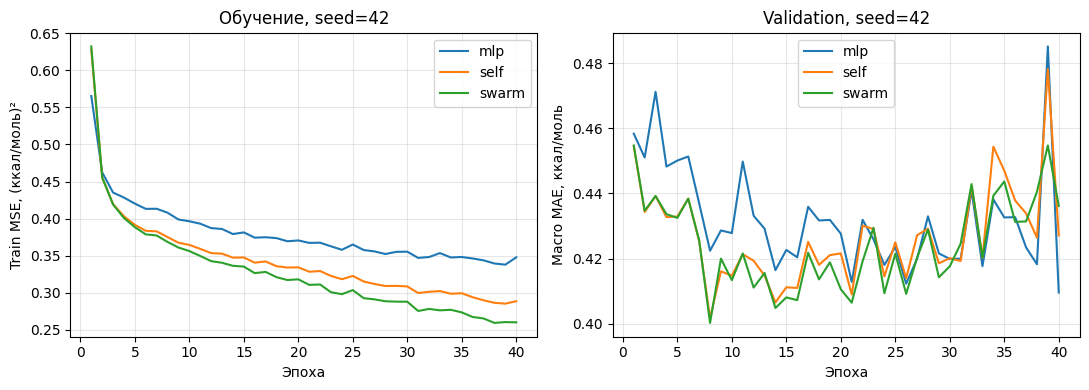

Результаты: /home/andre/Neuro_Project_Pilot/results/swarm_trainval_20260930_121141_532051
Веса: /home/andre/Neuro_Project_Pilot/weights/swarm_trainval_20260930_121141_532051


In [14]:
import matplotlib.pyplot as plt


averages = summary.groupby("model").agg(
    runs=("macro_MAE", "count"),
    macro_MAE_mean=("macro_MAE", "mean"),
    macro_MAE_std=("macro_MAE", "std"),
    pooled_RMSE_mean=("pooled_RMSE", "mean"),
)
display(averages.round(4))

paired = (
    summary.loc[summary["model"].isin(["self", "swarm"])]
    .pivot(index="seed", columns="model", values="macro_MAE")
)
paired["self_minus_swarm"] = paired["self"] - paired["swarm"]
display(paired.round(4))


fig, axes = plt.subplots(1, 2, figsize=(11, 4))

first_seed = SEEDS[0]

for kind in MODEL_KINDS:
    history = histories[(kind, first_seed)]

    axes[0].plot(
        history["epoch"], history["train_MSE"], label=kind
    )
    axes[1].plot(
        history["epoch"], history["macro_MAE"], label=kind
    )

axes[0].set(
    title=f"Обучение, seed={first_seed}",
    xlabel="Эпоха",
    ylabel="Train MSE, (ккал/моль)²",
)
axes[1].set(
    title=f"Validation, seed={first_seed}",
    xlabel="Эпоха",
    ylabel="Macro MAE, ккал/моль",
)

for ax in axes:
    ax.legend()
    ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(RESULTS_DIR / "learning_curves.png", dpi=150)
plt.show()

print("Результаты:", RESULTS_DIR)
print("Веса:", WEIGHTS_DIR)

## Итог запуска

Заполнить после просмотра результатов:

- Режим:
- Количество train/validation-белков:
- Прошло ли сравнение с исходным ThermoMPNN:
- Уменьшается ли обучающая ошибка:
- Лучший validation macro MAE каждого варианта:
- Разница self − SWARM:
- Время обучения:
- Замеченные проблемы:

После успешной технической проверки можно обсуждать основной запуск.

Режим trainval использует все официальные train/validation-белки.
40 эпох и выбранный learning rate — начальные настройки эксперимента,
а не воспроизведение авторского обучения или найденный оптимум.

Для окончательного вывода потребуются зафиксированный протокол,
несколько запусков и итоговая оценка на test.